In [ ]:
# -------- IMPORT LIBRARIES --------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
# -------- LOAD DATA --------
df_train = pd.read_csv("train_KNN.csv")
df_test = pd.read_csv("test_KNN.csv")

print(df_train.info())
print(df_test.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Sur

In [ ]:
# -------- CHECK MISSING VALUES --------
print(df_train.isnull().sum())

mp = 100 * (df_train.isnull().sum() / len(df_train))
mp = mp[mp > 0].sort_values()
print(mp)

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Embarked     0.224467
Age         19.865320
Cabin       77.104377
dtype: float64


In [ ]:
# -------- HANDLE MISSING VALUES (TRAIN) --------
df_train["Age"] = df_train["Age"].fillna(df_train["Age"].median())

# Drop rows where Embarked is missing
df_train = df_train.dropna(axis=0, subset=["Embarked"])

# Drop Cabin column
df_train = df_train.drop(["Cabin"], axis=1)

In [ ]:
# -------- HANDLE MISSING VALUES (TEST) --------
mpt = 100 * (df_test.isnull().sum() / len(df_test))
mpt = mpt[mpt > 0].sort_values()
print(mpt)

# Drop rows where Fare is missing
df_test = df_test.dropna(axis=0, subset=["Fare"])

# Fill Age missing values
df_test["Age"] = df_test["Age"].fillna(df_test["Age"].median())

# Drop Cabin column
df_test = df_test.drop(["Cabin"], axis=1)

Fare      0.239234
Age      20.574163
Cabin    78.229665
dtype: float64


In [ ]:
# -------- DROP IRRELEVANT COLUMNS --------
df_train.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)
df_test.drop(["PassengerId", "Name", "Ticket"], axis=1, inplace=True)


In [ ]:
# -------- CONVERT DATA TYPES --------
df_train["Survived"] = df_train["Survived"].apply(str)
df_train["Pclass"] = df_train["Pclass"].apply(str)

df_test["Survived"] = df_test["Survived"].apply(str)
df_test["Pclass"] = df_test["Pclass"].apply(str)

In [ ]:
# -------- SEPARATE NUMERIC & CATEGORICAL --------
df_train_num = df_train.select_dtypes(exclude="object")
df_train_obj = df_train.select_dtypes(include="object")

df_test_num = df_test.select_dtypes(exclude="object")
df_test_obj = df_test.select_dtypes(include="object")

In [ ]:
# -------- GET DUMMY VARIABLES --------
df_train_obj = pd.get_dummies(df_train_obj, drop_first=True)
df_test_obj = pd.get_dummies(df_test_obj, drop_first=True)


In [ ]:
# -------- COMBINE DATA --------
Final_train_df = pd.concat([df_train_num, df_train_obj, df_train["Survived"]], axis=1)
Final_test_df = pd.concat([df_test_num, df_test_obj, df_test["Survived"]], axis=1)


In [ ]:
# -------- REMPOVE TARGET VARIABLE --------
X_train = Final_train_df.drop("Survived", axis=1)
y_train = Final_train_df["Survived"]

X_test = Final_test_df.drop("Survived", axis=1)
y_test = Final_test_df["Survived"]

In [ ]:
# -------- STANDARDIZING DATA --------
scaler = StandardScaler()

scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

KNN Accuracy: 0.9928057553956835
KNN Confusion Matrix:
 [[265   0]
 [  3 149]]


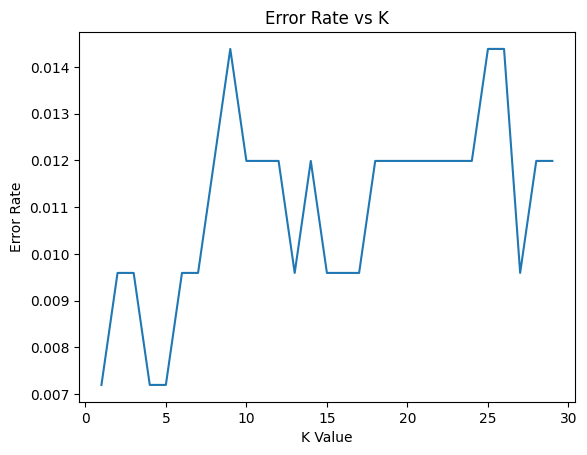

In [ ]:
# ==============================
# MODEL 1: KNN
# ==============================
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(scaled_X_train, y_train)

y_pred_knn = knn.predict(scaled_X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

# -------- K VALUE ANALYSIS --------
Performance_Metric = []

for k in range(1, 30):
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(scaled_X_train, y_train)
    y_pred_k = knn_k.predict(scaled_X_test)
    error = 1 - accuracy_score(y_test, y_pred_k)
    Performance_Metric.append(error)

plt.plot(range(1, 30), Performance_Metric)
plt.title("Error Rate vs K")
plt.xlabel("K Value")
plt.ylabel("Error Rate")
plt.show()

In [ ]:
# ==============================
# MODEL 2: LOGISTIC REGRESSION
# ==============================
lr = LogisticRegression(max_iter=1000)
lr.fit(scaled_X_train, y_train)

y_pred_lr = lr.predict(scaled_X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))


Logistic Regression Accuracy: 1.0
Logistic Regression Confusion Matrix:
 [[265   0]
 [  0 152]]


In [ ]:
# ==============================
# MODEL 3: DECISION TREE
# ==============================
dt = DecisionTreeClassifier(random_state=42)
dt.fit(scaled_X_train, y_train)

y_pred_dt = dt.predict(scaled_X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))


Decision Tree Accuracy: 1.0
Decision Tree Confusion Matrix:
 [[265   0]
 [  0 152]]


In [ ]:
# ==============================
# MODEL COMPARISON
# ==============================
print("\nModel Comparison")
print("---------------------")
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Model Comparison
---------------------
KNN Accuracy: 0.9928057553956835
Logistic Regression Accuracy: 1.0
Decision Tree Accuracy: 1.0


INSIGHTS :


LOGISTIC REGRESSION & DECISION TREE:   

   1. Predicted all the survivors correctly
   2. Predicted all the non-survivors correctly
   3. Have a perfect Accuracy score of 1
   4. Impossible in real-world situations, there might be mistakes in data collection process.

KNN CLASSIFICATION:

   1. Misspredicted 3 non-survivors as survivors
   2. Accuracy is slightly less than that of Logistic Regression and Decision Tree
   3. Maybe due to uneven distribution in data

OVERALL:
   
   1. Logistic Regression is best for binary classification
   2. Followed by Desicion Tree (has a tendency to overfit)
   3. KNN is the least favoured among these (due to sensitivity to noise and uneven spread of data)

